#  Day 1: Time-Based Advanced EDA

In [5]:
#download data from kaggle
!pip install opendatasets

In [6]:
import pandas as pd
import numpy as np
import opendatasets as od
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [7]:
od.download("https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset", parse_dates=['Order Date', 'Ship Date'])


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: hemantk777
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset


100%|██████████| 11.1M/11.1M [00:00<00:00, 757MB/s]

In [8]:
df = pd.read_csv("/content/global-super-store-dataset/Global_Superstore2.csv", encoding='latin1')

In [9]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [11]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [12]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [13]:
# extract dates
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['MonthName'] = df['Order Date'].dt.strftime('%b')
df['YearMonth'] = df['Order Date'].dt.to_period('M')

/tmp/ipython-input-13-2564032370.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


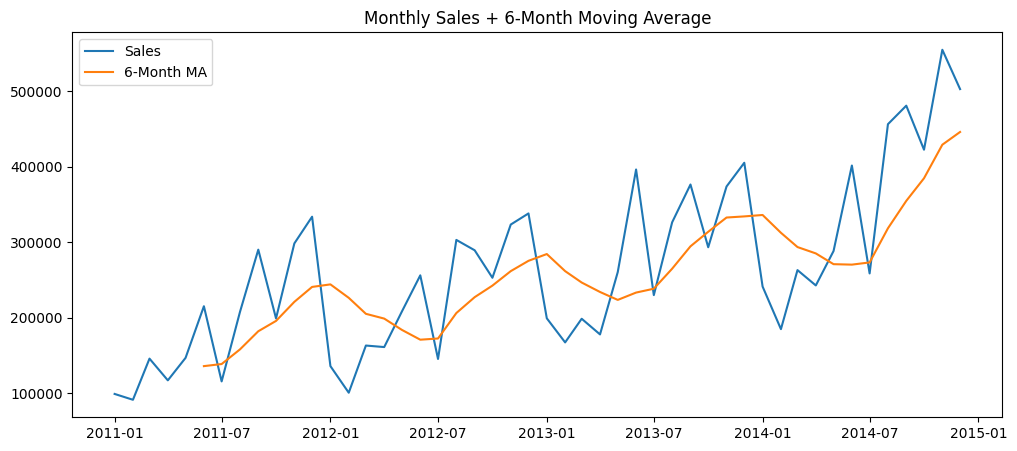

In [14]:
# Monthly Sales & Profit Trend
ts = df.groupby("YearMonth")[["Sales","Profit"]].sum().reset_index()
ts['Sales_MA6'] = ts['Sales'].rolling(6).mean()
ts['Profit_MA6'] = ts['Profit'].rolling(6).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts['YearMonth'].dt.to_timestamp(), ts['Sales'], label='Sales')
plt.plot(ts['YearMonth'].dt.to_timestamp(), ts['Sales_MA6'], label='6‑Month MA')
plt.title("Monthly Sales + 6‑Month Moving Average")
plt.legend()
#plt.savefig("monthly_sales_ma.png")
plt.show()


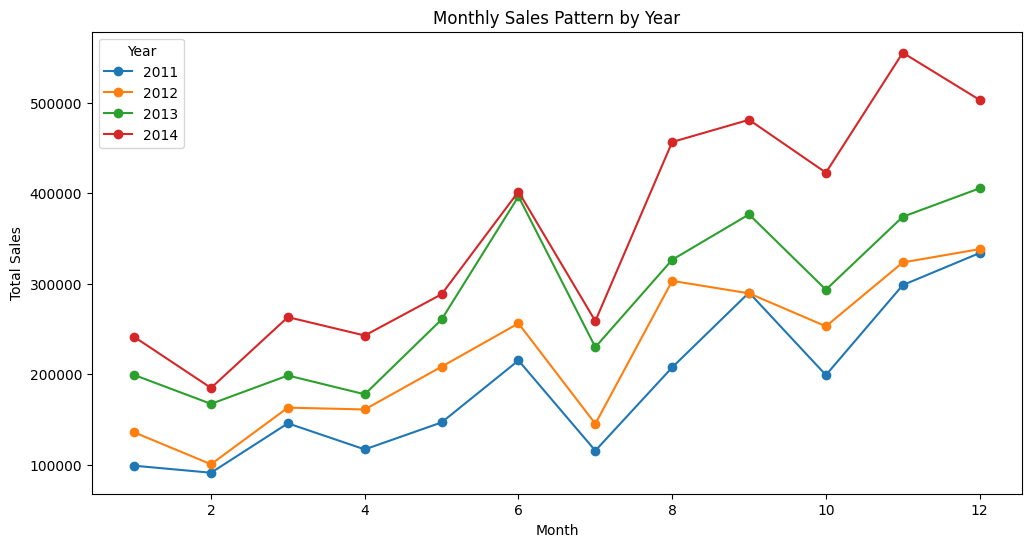

In [15]:
# Yearly Comparison / Seasonality Check
pivot = df.pivot_table(index='Month', columns='Year', values='Sales', aggfunc='sum')
pivot.plot(figsize=(12,6), marker='o')
plt.title("Monthly Sales Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(title='Year')
#plt.savefig("Monthly Sales Pattern by Year.png")
plt.show()


# Day 2: Grouped Metrics & Profit Leak Investigation

In [16]:
#Sales, Profit by Category + Sub-Category
category_perf = df.groupby(['Category', 'Sub-Category'])[["Sales","Profit"]].sum().sort_values('Profit', ascending=False).reset_index()

category_perf.head(10)

,Category,Sub-Category,Sales,Profit
0,Technology,Copiers,1.509436e+06,258567.54818
1,Technology,Phones,1.706824e+06,216717.00580
2,Furniture,Bookcases,1.466572e+06,161924.41950
3,Office Supplies,Appliances,1.011064e+06,141680.58940
4,Furniture,Chairs,1.501682e+06,140396.26750
5,Technology,Accessories,7.492370e+05,129626.30620
6,Office Supplies,Storage,1.127086e+06,108461.48980
7,Office Supplies,Binders,4.619115e+05,72449.84600
8,Office Supplies,Paper,2.442917e+05,59207.68270
9,Technology,Machines,7.790601e+05,58867.87300


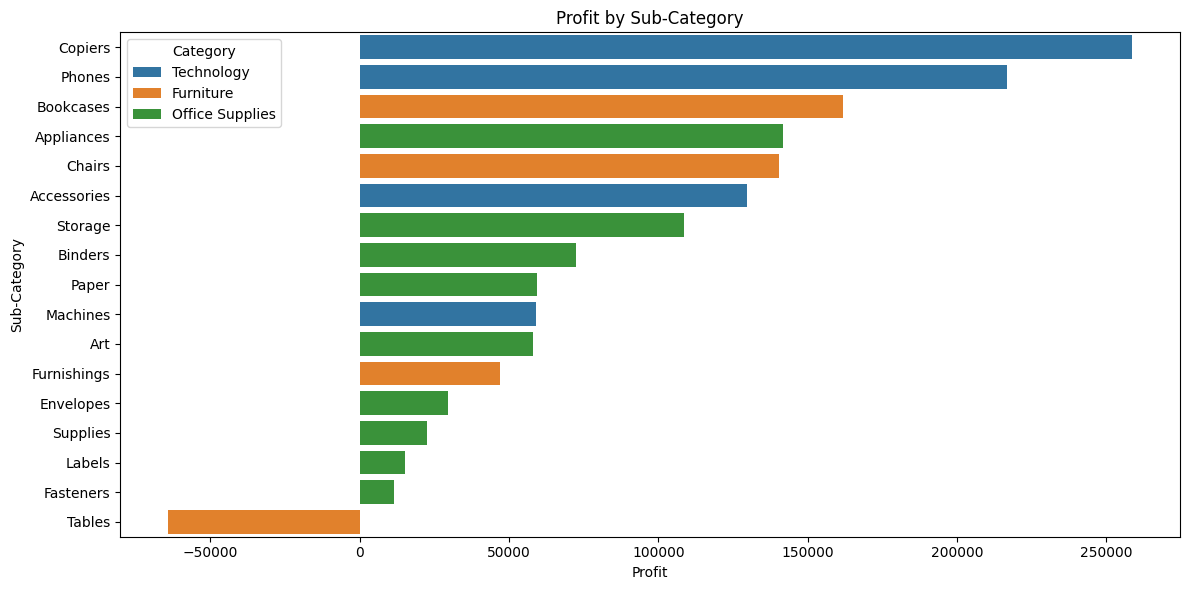

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(data=category_perf, y='Sub-Category', x='Profit', hue='Category')
plt.title("Profit by Sub-Category")
plt.tight_layout()
#plt.savefig("Profit by Sub-Category.png")
plt.show()

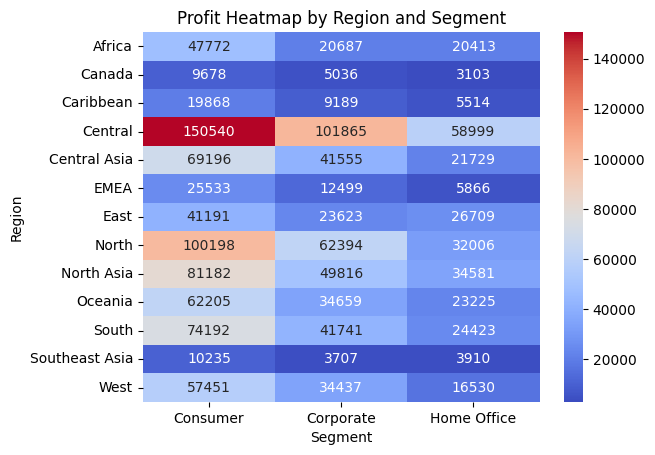

In [18]:
#  Region & Segment Wise Analysis
region_perf = df.groupby(['Region', 'Segment'])[["Sales","Profit"]].sum().reset_index()

pivot = region_perf.pivot(index='Region', columns='Segment', values='Profit')

sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')
plt.title("Profit Heatmap by Region and Segment")
#plt.savefig("Profit Heatmap by Region and Segment.png")
plt.show()

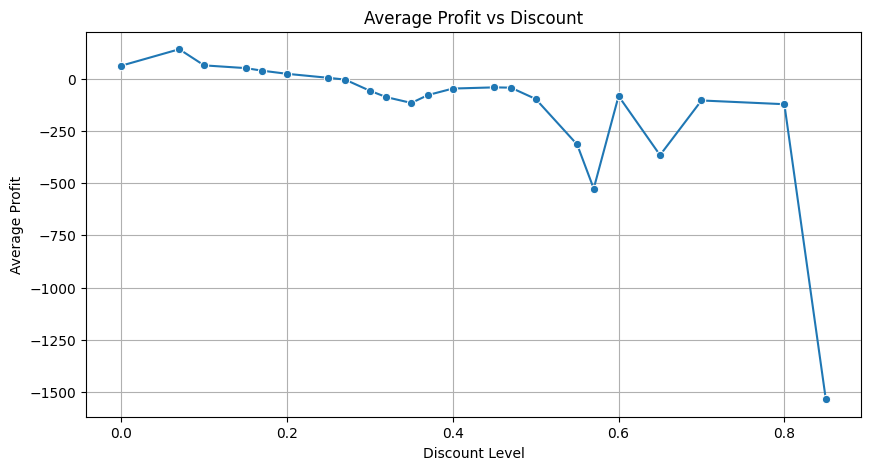

In [19]:
#Discount vs Profit (Is discount hurting us?)
df['Discount_Rounded'] = df['Discount'].round(2)

disc_profit = df.groupby('Discount_Rounded')['Profit'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=disc_profit, x='Discount_Rounded', y='Profit', marker='o')
plt.title("Average Profit vs Discount")
plt.xlabel("Discount Level")
plt.ylabel("Average Profit")
plt.grid(True)
#plt.savefig("Average Profit vs Discount.png")
plt.show()


In [20]:
# Most Unprofitable Records (Profit Leaks)
loss_df = df[df['Profit'] < 0].sort_values('Profit')
loss_df[['Order ID', 'Product Name', 'Sales', 'Profit', 'Discount', 'Category']].head(10)

,Order ID,Product Name,Sales,Profit,Discount,Category
171,CA-2013-108196,Cubify CubeX 3D Printer Double Head Print,4499.985,-6599.9780,0.7,Technology
6591,TU-2013-9400,"Motorola Smart Phone, Cordless",3085.344,-4088.3760,0.6,Technology
37,US-2014-168116,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,0.5,Technology
1341,CA-2011-169019,GBC DocuBind P400 Electric Binding System,2177.584,-3701.8928,0.8,Office Supplies
2347,CA-2014-134845,Lexmark MX611dhe Monochrome Laser Printer,2549.985,-3399.9800,0.7,Technology
512,IT-2013-3695467,"Hoover Stove, White",3399.660,-3059.8200,0.5,Office Supplies
362,ID-2013-12295,"Apple Smart Phone, Full Size",3499.155,-3009.4350,0.5,Technology
2101,US-2014-122714,Ibico EPK-21 Electric Binding System,1889.990,-2929.4845,0.8,Office Supplies
245,LH-2014-5390,"Barricks Conference Table, Rectangular",2171.160,-2750.2800,0.7,Furniture
859,CA-2012-147830,Cubify CubeX 3D Printer Double Head Print,1799.994,-2639.9912,0.7,Technology


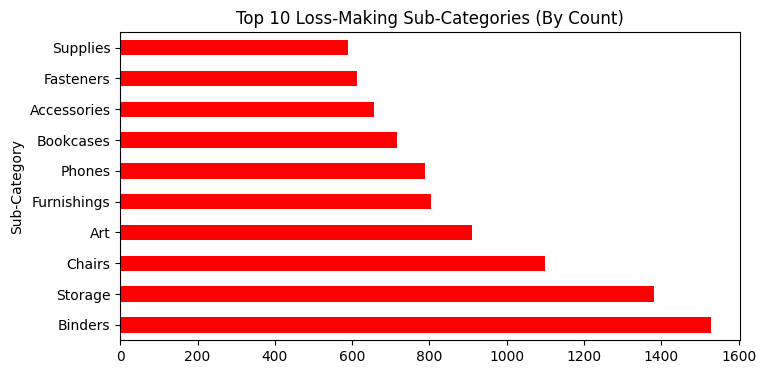

In [21]:
# sub-categories with highest loss counts.
loss_counts = loss_df['Sub-Category'].value_counts().head(10)

plt.figure(figsize=(8,4))
loss_counts.plot(kind='barh', color='red')
plt.title("Top 10 Loss-Making Sub-Categories (By Count)")
#plt.savefig("Top 10 Loss-Making Sub-Categories (By Count).png")
plt.show()

# Day 3: Advanced Customer & Order Behavior Analysis

In [22]:
# Prepare Date Column
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [23]:
# RFM Analysis (Recency, Frequency, Monetary)
latest_date = df['Order Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (latest_date - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
rfm.sort_values(by='Monetary', ascending=False).head()

,Customer ID,Recency,Frequency,Monetary
1463,TA-21385,18,25,35668.12080
623,GT-14710,8,30,34471.89028
1489,TC-20980,27,28,34218.26900
1405,SM-20320,21,21,31125.29496
237,BW-11110,54,35,30613.61650


In [24]:
# Segment Customers Based on RFM Quantiles

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,AA-10315,8,19,13747.41300,4,3,4,434
1,AA-10375,6,23,5884.19500,4,3,2,432
2,AA-10480,125,20,17695.58978,1,3,4,134
3,AA-10645,28,36,15343.89070,3,4,4,344
4,AA-315,2,7,2243.25600,4,2,2,422


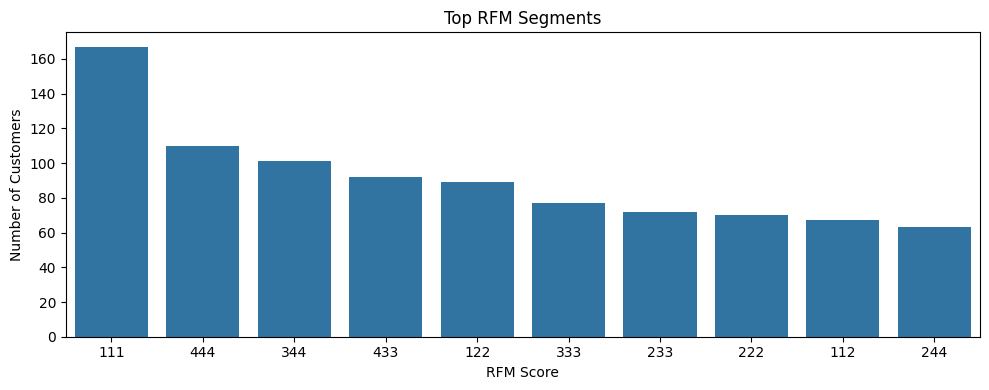

In [25]:
# Visualize Top Segments
top_segments = rfm['RFM_Score'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_segments.index, y=top_segments.values)
plt.title("Top RFM Segments")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")
plt.tight_layout()
#plt.savefig("Top RFM Segments.png")
plt.show()

In [26]:
# Top Customers by Sales and Profit
top_customers = df.groupby(['Customer ID', 'Customer Name'])[["Sales","Profit"]].sum().sort_values('Sales', ascending=False).head(10)
#top_customers.to_csv("top_customers.csv", index=True)   #save table
top_customers

,,Sales,Profit
Customer ID,Customer Name,,
TA-21385,Tom Ashbrook,35668.12080,6274.98910
GT-14710,Greg Tran,34471.89028,5164.84718
TC-20980,Tamara Chand,34218.26900,8787.47490
SM-20320,Sean Miller,31125.29496,-1083.67434
BW-11110,Bart Watters,30613.61650,3337.46590
HL-15040,Hunter Lopez,29664.23058,7657.50178
SE-20110,Sanjit Engle,29532.62502,5863.62392
PS-19045,Penelope Sewall,29252.31940,4426.19510
RB-19360,Raymond Buch,29197.63460,8523.95150


In [27]:
# High-Value Orders (Flag Big Spenders)
high_value_orders = df[df['Sales'] > 1000].sort_values(by='Sales', ascending=False)
high_value_orders[['Order ID', 'Customer Name', 'Sales', 'Profit']].head()

,Order ID,Customer Name,Sales,Profit
12887,CA-2011-145317,Sean Miller,22638.480,-1811.0784
329,CA-2013-118689,Tamara Chand,17499.950,8399.9760
14843,CA-2014-140151,Raymond Buch,13999.960,6719.9808
7399,CA-2014-127180,Tom Ashbrook,11199.968,3919.9888
290,CA-2014-166709,Hunter Lopez,10499.970,5039.9856


In [28]:
# Repeat Customers (Multiple Orders)
order_counts = df.groupby('Customer ID')['Order ID'].nunique().reset_index()
repeat_customers = order_counts[order_counts['Order ID'] > 1].shape[0]

print("Number of repeat customers:", repeat_customers)

Number of repeat customers: 1580


# Day 4: Time Series & Seasonal Sales Trend Analysis

In [30]:
df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)

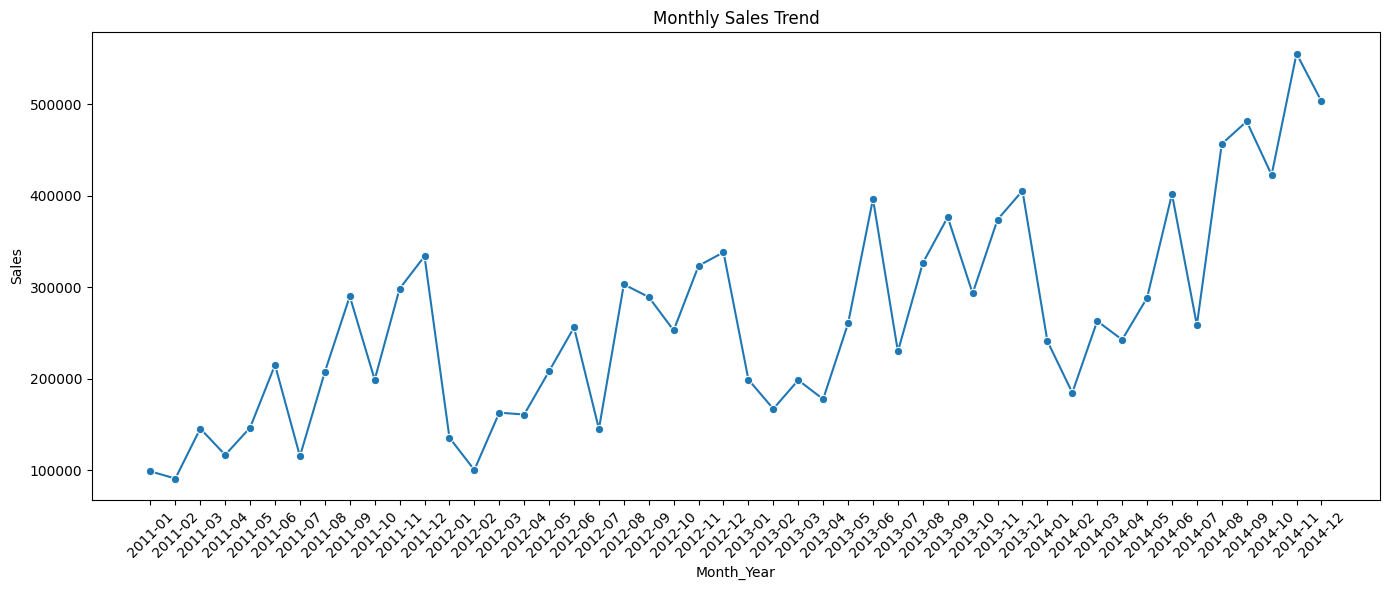

In [32]:
# Plot Monthly Sales Trends
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales, x='Month_Year', y='Sales', marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.tight_layout()
#plt.savefig("Monthly Sales Trend.png")
plt.show()

/tmp/ipython-input-33-3778805977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_sales, x='Year', y='Sales', palette='viridis')


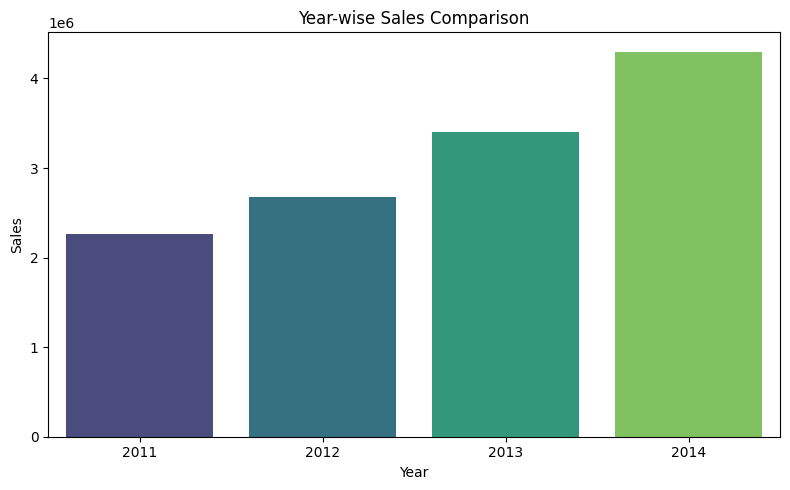

In [33]:
# Year-over-Year Sales Growth
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=yearly_sales, x='Year', y='Sales', palette='viridis')
plt.title("Year-wise Sales Comparison")
plt.tight_layout()
#plt.savefig("Year-wise Sales Comparison.png")
plt.show()

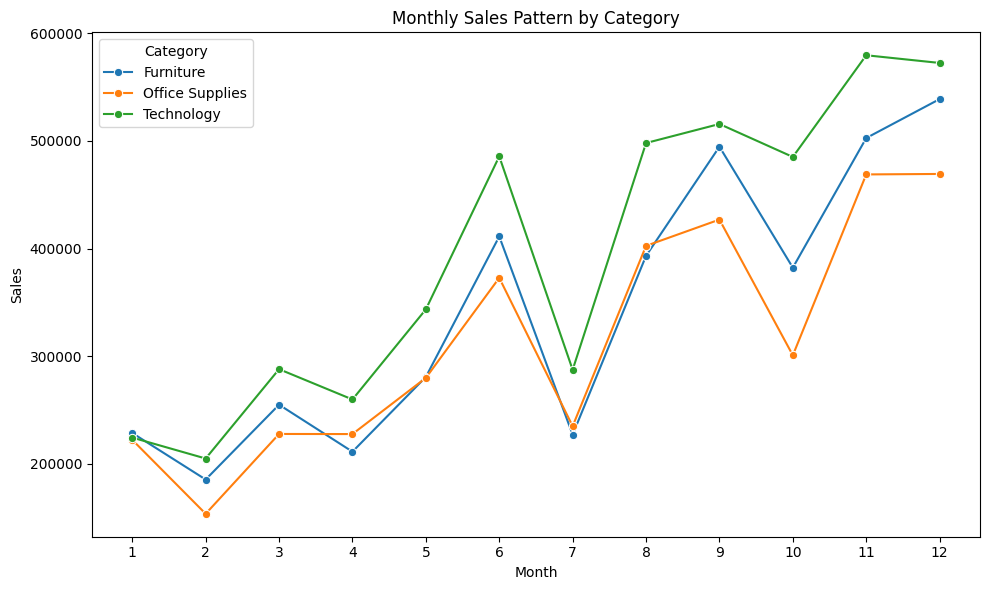

In [36]:
# Category-wise Seasonal Patterns (Line Plot)
cat_monthly = df.groupby(['Month', 'Category'])['Sales'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=cat_monthly, x='Month', y='Sales', hue='Category', marker='o')
plt.title("Monthly Sales Pattern by Category")
plt.xticks(range(1,13))
plt.tight_layout()
#plt.savefig("Monthly Sales Pattern by Category.png")
plt.show()

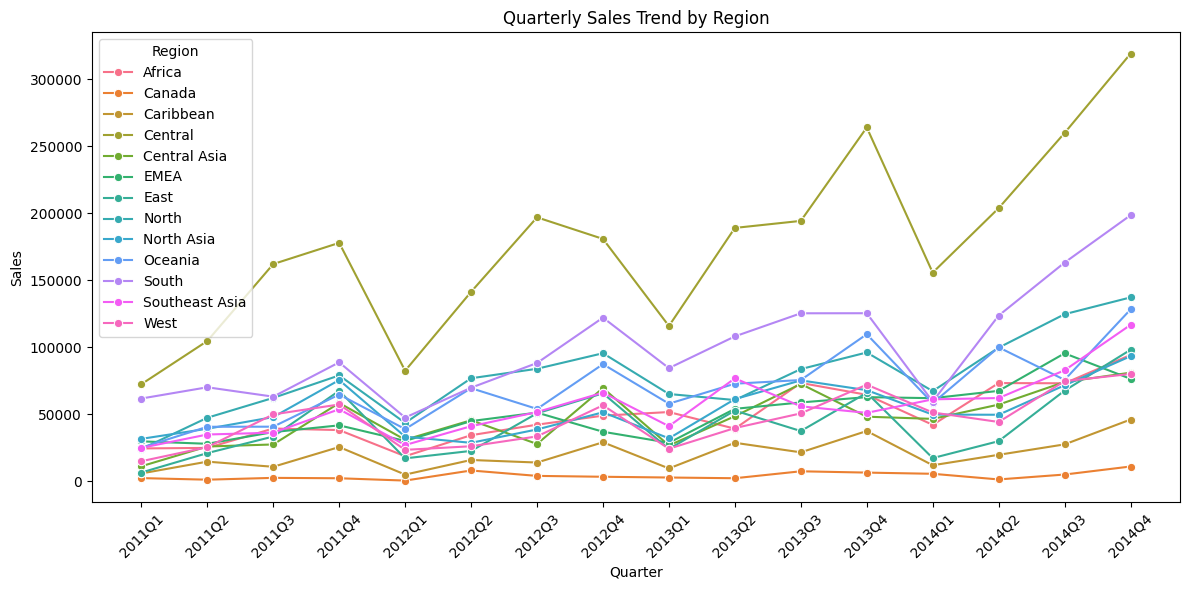

In [38]:
# Region-wise Quarterly Sales Trends
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
quarterly_region = df.groupby(['Quarter', 'Region'])['Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=quarterly_region, x='Quarter', y='Sales', hue='Region', marker='o')
plt.xticks(rotation=45)
plt.title("Quarterly Sales Trend by Region")
plt.tight_layout()
#plt.savefig("Quarterly Sales Trend by Region.png")
plt.show()